#  **Exoplanet Analyzer**

##  Project Overview

Exoplanets are planets that orbit stars outside our solar system. Over the past few decades, astronomers have discovered thousands of these distant worlds using advanced observational techniques. One of the most successful missions dedicated to this search was the Kepler Space Telescope, which continuously monitored the brightness of thousands of stars in order to detect potential planetary systems.

A widely used technique for detecting exoplanets is the **Transit Method**. When a planet passes in front of its host star from our point of view, it blocks a very small portion of the star’s light. This causes a slight but measurable decrease in the observed brightness of the star.

These variations in brightness are represented using a **stellar light curve**, which is a graph showing how the brightness (flux) of a star changes over time. For a normal star, the brightness remains relatively stable. However, if a planet is orbiting the star and periodically crosses in front of it, the light curve shows small dips in brightness corresponding to these transit events.

##  Objective of This Project

The goal of this project is to analyze stellar light curve data and apply machine learning techniques to identify stars that may contain exoplanets. Using brightness measurements collected from astronomical observations, the project explores patterns in stellar flux data and trains a classification model capable of distinguishing between stars with exoplanets and those without them.

Through data preprocessing, visualization, and model evaluation, this project demonstrates how data science can be applied to real astronomical datasets to assist in the detection of exoplanets.

## Data Loading


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_data = pd.read_csv("../data/raw/exoTrain.csv")
test_data = pd.read_csv("../data/raw/exoTest.csv")

In [4]:
train_data.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


## Data Exploration

In [5]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB


In [6]:
train_data.shape

(5087, 3198)

In [7]:
train_data["LABEL"].value_counts()

LABEL
1    5050
2      37
Name: count, dtype: int64

In [25]:
train_data.describe()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5087.000000,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,0.992727,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,...,3.485578e+02,4.956476e+02,6.711211e+02,7.468790e+02,6.937372e+02,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,0.084982,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,...,2.864786e+04,3.551876e+04,4.349963e+04,4.981375e+04,5.087103e+04,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,0.000000,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,...,-3.240480e+05,-3.045540e+05,-2.933140e+05,-2.838420e+05,-3.288214e+05,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,1.000000,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,...,-1.760000e+01,-1.948500e+01,-1.757000e+01,-2.076000e+01,-2.226000e+01,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,1.000000,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,...,2.600000e+00,2.680000e+00,3.050000e+00,3.590000e+00,3.230000e+00,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,1.000000,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,...,2.211000e+01,2.235000e+01,2.639500e+01,2.909000e+01,2.780000e+01,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,1.000000,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,...,1.779338e+06,2.379227e+06,2.992070e+06,3.434973e+06,3.481220e+06,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


## Data Visualization

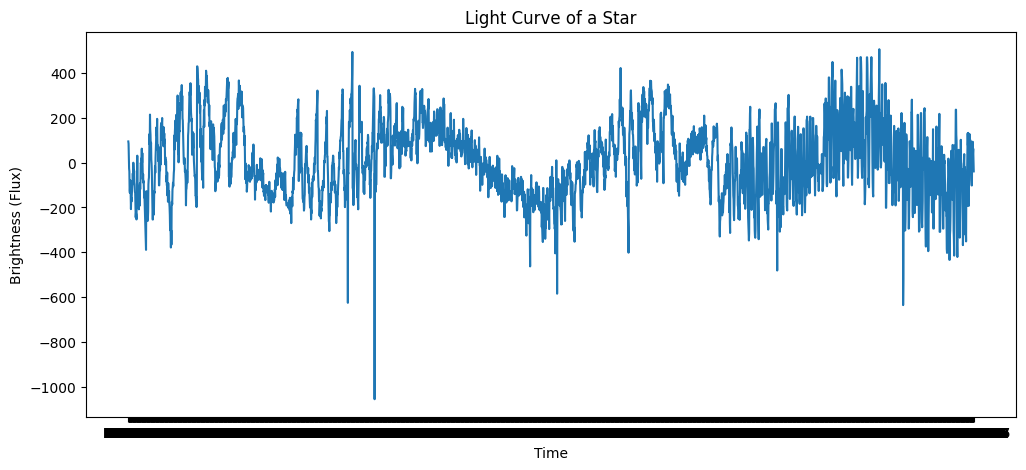

In [8]:
flux_values = train_data.iloc[0, 1:]

plt.figure(figsize=(12,5))
plt.plot(flux_values)

plt.title("Light Curve of a Star")
plt.xlabel("Time")
plt.ylabel("Brightness (Flux)")

plt.savefig("../output/star_light_curve.png")


plt.show()

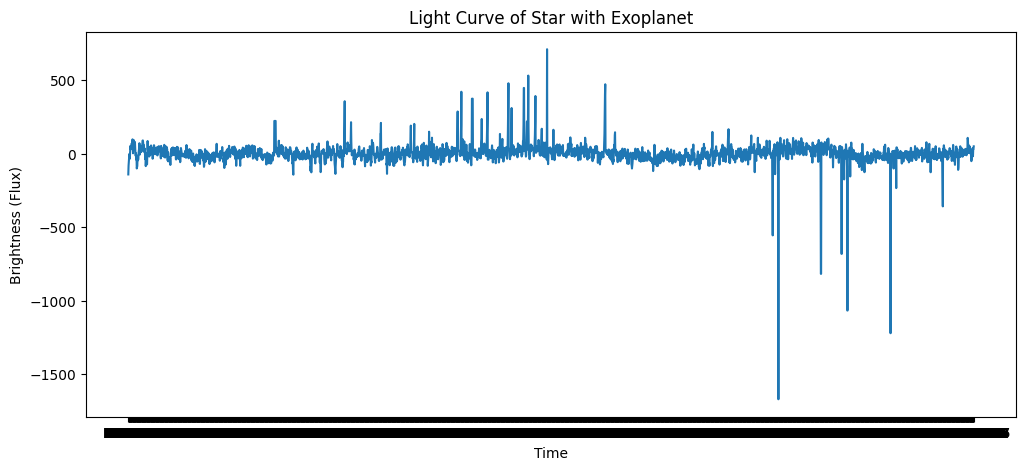

In [9]:
planet_star = train_data[train_data["LABEL"] == 1].iloc[0, 1:]

plt.figure(figsize=(12,5))
plt.plot(planet_star)

plt.title("Light Curve of Star with Exoplanet")
plt.xlabel("Time")
plt.ylabel("Brightness (Flux)")

plt.savefig("../output/exoplanet_light_curve.png")

plt.show()

## Model Training

In [10]:
train_data["LABEL"] = train_data["LABEL"].replace({2:0})
test_data["LABEL"] = test_data["LABEL"].replace({2:0})

In [11]:
train_data["LABEL"].value_counts()

LABEL
1    5050
0      37
Name: count, dtype: int64

In [12]:
X_train = train_data.drop("LABEL", axis=1)
y_train = train_data["LABEL"]

X_test = test_data.drop("LABEL", axis=1)
y_test = test_data["LABEL"]

In [13]:
print(X_train.shape)
print(y_train.shape)

(5087, 3197)
(5087,)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
print(X_train_scaled[0][:10])

[-0.00235557 -0.00205404 -0.00579778 -0.00823747 -0.00847872 -0.01127126
 -0.01044041 -0.00920199 -0.00964358 -0.01551184]


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [17]:
pd.Series(y_train_balanced).value_counts()

LABEL
0    5050
1    5050
Name: count, dtype: int64

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train_balanced, y_train_balanced)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9912280701754386


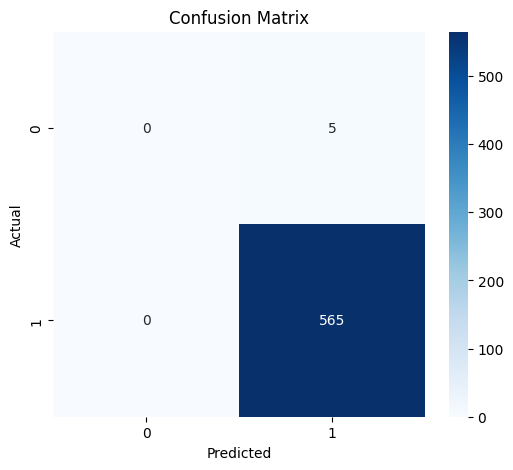

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("../output/confusion_matrix.png")

plt.show()

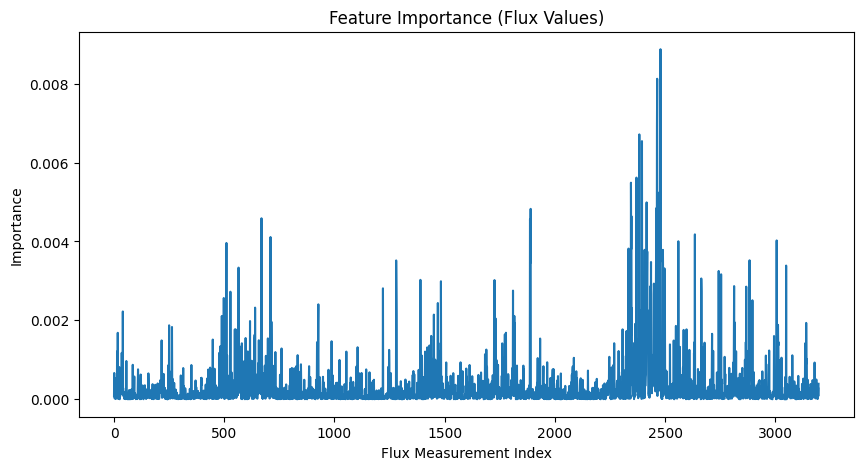

In [22]:
importances = model.feature_importances_

plt.figure(figsize=(10,5))
plt.plot(importances)

plt.title("Feature Importance (Flux Values)")
plt.xlabel("Flux Measurement Index")
plt.ylabel("Importance")

plt.savefig("../output/feature_importance.png")

plt.show()

In [23]:
import pickle

with open("../models/exoplanet_classifier.pkl", "wb") as f:
    pickle.dump(model, f)

In [24]:
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

## 🧾 Conclusion

In this project, an **Exoplanet Analyzer** was developed to detect potential exoplanets using stellar brightness data. The project was implemented using **Python** and several data science libraries including **Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn** for data analysis, visualization, and machine learning. The dataset containing stellar flux measurements was first explored and preprocessed to prepare it for analysis. Light curve visualizations were generated to understand how the brightness of stars changes over time and how the presence of an exoplanet creates small dips in stellar brightness when it transits the star.

After preprocessing the data, a **machine learning classification model** was trained to distinguish between stars that contain exoplanets and those that do not. The model learned patterns in the stellar flux measurements that indicate possible planetary transits. Several visualizations such as **light curves, confusion matrix, and feature importance plots** were created to better understand both the dataset and the model’s behavior.

The evaluation results showed that the model performs extremely well on the dataset. Based on the confusion matrix and prediction results, the classifier achieved an **accuracy of approximately 99%**, correctly identifying almost all stars containing exoplanets while making very few incorrect predictions. This indicates that the model was able to successfully learn the brightness patterns associated with planetary transits.

Overall, this project demonstrates how **data analysis and machine learning techniques can be applied to astronomical datasets** to assist in the detection of exoplanets. By analyzing stellar light curves and identifying subtle variations in brightness, computational models can help astronomers efficiently analyze large volumes of observational data and identify potential exoplanet candidates.